In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

1: MEMBUAT DATASET SIMULASI GAME STEAM

In [3]:
np.random.seed(42)
n_samples = 2500

# Membuat fitur-fitur sesuai bab Data Understanding
positive_reviews = np.random.randint(10, 5000, n_samples)
negative_reviews = np.random.randint(5, 2000, n_samples)
english = np.random.choice([0, 1], n_samples, p=[0.1, 0.9])
achievements = np.random.randint(0, 100, n_samples)
average_playtime = np.random.randint(10, 2400, n_samples)

# Membuat target kelas harga (0: Murah, 1: Sedang, 2: Premium) berdasarkan logika fitur
price_score = (positive_reviews * 0.4) + (average_playtime * 0.3) + (achievements * 10) - (negative_reviews * 0.2)
price_class = np.where(price_score < 1000, 0, np.where(price_score < 3000, 1, 2))

# Menggabungkan menjadi DataFrame
df = pd.DataFrame({
    'positive_reviews': positive_reviews,
    'negative_reviews': negative_reviews,
    'english': english,
    'achievements': achievements,
    'average_playtime': average_playtime,
    'price_class': price_class
})

print("Dataset berhasil dibuat!")
print(f"Ukuran data: {df.shape[0]} baris dan {df.shape[1]} kolom.")
print("\n5 Data Teratas:")
print(df.head())

Dataset berhasil dibuat!
Ukuran data: 2500 baris dan 6 kolom.

5 Data Teratas:
   positive_reviews  negative_reviews  english  achievements  \
0               870               181        1            25   
1              3782               533        1            56   
2              3102              1638        1            23   
3               476               970        1            52   
4              4436              1522        1            69   

   average_playtime  price_class  
0              1726            1  
1              1293            1  
2               600            1  
3              1996            1  
4              1011            1  


STEP 2: EDA, PREPARATION, DAN MODELING

--- Memproses Visualisasi Data ---


/tmp/ipykernel_2179/4122047610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_class', data=df, palette='Set2')


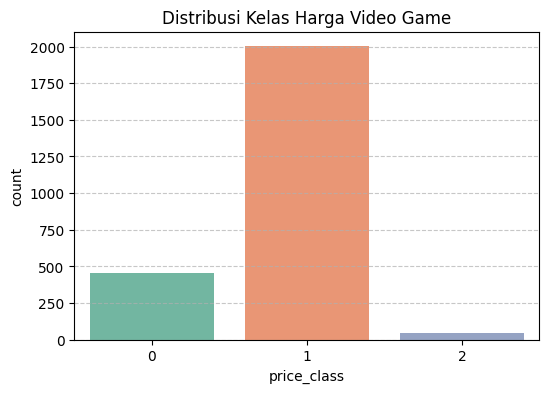

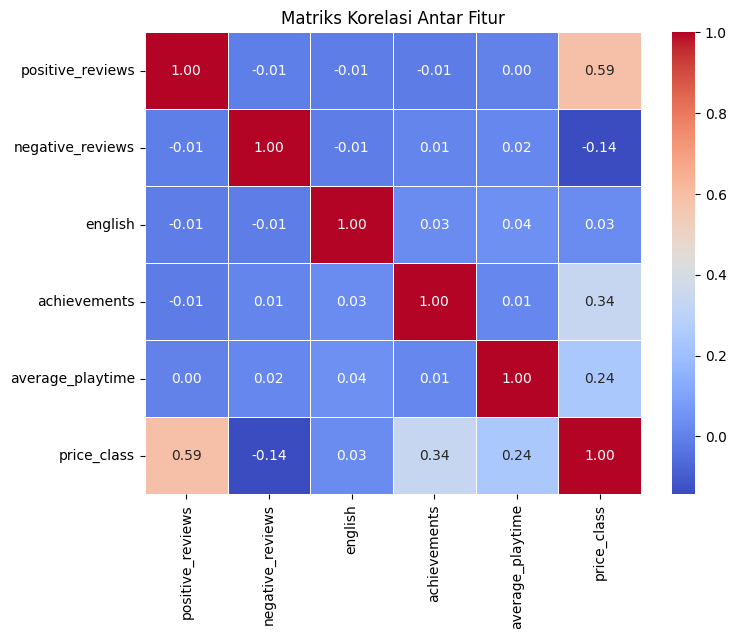


======= HASIL EVALUASI MODEL =======
Akurasi Model Decision Tree: 90.80%
Akurasi Model K-Nearest Neighbors (KNN): 87.80%


In [4]:
# --- 1. VISUALISASI EDA ---
print("--- Memproses Visualisasi Data ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='price_class', data=df, palette='Set2')
plt.title('Distribusi Kelas Harga Video Game')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

# --- 2. DATA PREPARATION ---
X = df.drop('price_class', axis=1)
y = df['price_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. MODELING & EVALUATION ---
p_model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
p_model_knn = KNeighborsClassifier(n_neighbors=5)

p_model_dt.fit(X_train, y_train)
p_model_knn.fit(X_train, y_train)

y_pred_dt = p_model_dt.predict(X_test)
y_pred_knn = p_model_knn.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt) * 100
acc_knn = accuracy_score(y_test, y_pred_knn) * 100

print("\n======= HASIL EVALUASI MODEL =======")
print(f"Akurasi Model Decision Tree: {acc_dt:.2f}%")
print(f"Akurasi Model K-Nearest Neighbors (KNN): {acc_knn:.2f}%")